<a href="https://colab.research.google.com/github/nikolaperic03/duboko-ucenje-i-neuronske-mreze/blob/main/Neuronske.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Projekat Duboko ucenje i neuronske mreze - Tema : Primena neuronskih mreža za predvidjanje prevara u cyber bezbednosti (spam, dos napadi)**


## Instalacija i import biblioteka



In [1]:
!pip -q install sentence-transformers

In [15]:
import pandas as pd
import warnings

import torch
from torch.utils.data import TensorDataset, random_split, DataLoader
from torch.optim import Adam
from torch.nn import CrossEntropyLoss
import torch.nn as nn
import torch.nn.functional as F

from sklearn.utils import resample
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.model_selection import train_test_split
import torch

from sentence_transformers import SentenceTransformer
from collections import defaultdict

import seaborn as sb
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')


In [3]:
RAND_STATE = 1
PRETRAINED_LM = "all-MiniLM-L12-v2"

## Ucitavanje i priprema podataka

In [4]:
from google.colab import files
# https://www.kaggle.com/datasets/ashfakyeafi/spam-email-classification?resource=download
data_file = files.upload()
file_name = list(data_file.keys())[0]

Saving email.csv to email.csv


In [5]:
data = pd.read_csv(file_name)
data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5573 non-null   object
 1   Message   5573 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [7]:
data.describe()

,Category,Message
count,5573,5573
unique,3,5158
top,ham,"Sorry, I'll call later"
freq,4825,30


In [8]:
data.Category.value_counts()

,count
Category,
ham,4825
spam,747
"{""mode"":""full""",1


In [9]:
data.Message.value_counts()[data.Message.value_counts() > 1]

,count
Message,
"Sorry, I'll call later",30
I cant pick the phone right now. Pls send a message,12
Ok...,10
Your opinion about me? 1. Over 2. Jada 3. Kusruthi 4. Lovable 5. Silent 6. Spl character 7. Not matured 8. Stylish 9. Simple Pls reply..,4
"Say this slowly.? GOD,I LOVE YOU &amp; I NEED YOU,CLEAN MY HEART WITH YOUR BLOOD.Send this to Ten special people &amp; u c miracle tomorrow, do it,pls,pls do it...",4
...,...
"God picked up a flower and dippeditinaDEW, lovingly touched itwhichturnedinto u, and the he gifted tomeandsaid,THIS FRIEND IS 4U",2
Purity of friendship between two is not about smiling after reading the forwarded message..Its about smiling just by seeing the name. Gud evng,2
Hi Dear Call me its urgnt. I don't know whats your problem. You don't want to work or if you have any other problem at least tell me. Wating for your reply.,2


Brisanje duplikata

In [10]:
data = data.drop_duplicates(subset='Message').reset_index(drop=True)

Provera

In [11]:
len(data.Message.value_counts()[data.Message.value_counts() > 1])

0

In [12]:
data.shape

(5158, 2)

Balansiranje dataseta - Downsampling

In [13]:
data.Category.value_counts(normalize=True)

,proportion
Category,
ham,0.875533
spam,0.124273
"{""mode"":""full""",0.000194


In [14]:
data_majority = data[data.Category == 'ham']
data_minority = data[data.Category == 'spam']

In [16]:
data_majority_downsampled = resample(
    data_majority,
    replace=False,
    n_samples=len(data_minority),
    random_state=RAND_STATE
)

In [17]:
data_balanced = pd.concat([data_majority_downsampled, data_minority])
data_balanced = data_balanced.reset_index(drop=True)

In [18]:
# "Izmešaćemo" podatke
data_balanced = data_balanced.sample(frac=1, random_state=RAND_STATE).reset_index(drop=True)

In [19]:
data_balanced.head(5)

,Category,Message
0,ham,"Yep, by the pretty sculpture"
1,ham,Yes just finished watching days of our lives. ...
2,spam,Congratulations! Thanks to a good friend U hav...
3,ham,So how many days since then?
4,spam,Free 1st week entry 2 TEXTPOD 4 a chance 2 win...


In [20]:
data_balanced.Category.value_counts()

,count
Category,
ham,641
spam,641


In [21]:
data_balanced.shape

(1282, 2)

Transformacija rezultujuce kolone spam - 1 ; ham - 0

In [22]:
data_balanced['Category'] = data_balanced.Category.apply(lambda cat: 1 if cat == 'spam' else 0)

In [23]:
data_balanced.Category.value_counts()

,count
Category,
0,641
1,641


In [24]:
data_balanced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1282 entries, 0 to 1281
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  1282 non-null   int64 
 1   Message   1282 non-null   object
dtypes: int64(1), object(1)
memory usage: 20.2+ KB


**Dodavanje numericke kolone - Duzina teksta poruke**

In [25]:
data_balanced['length'] = data_balanced.Message.apply(len)

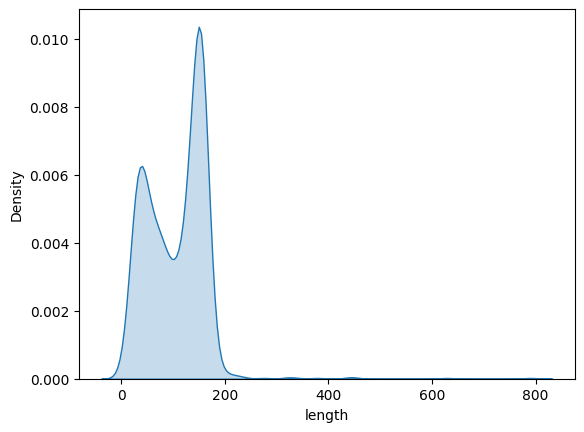

In [26]:
sb.kdeplot(data_balanced.length, fill=True)
plt.show()

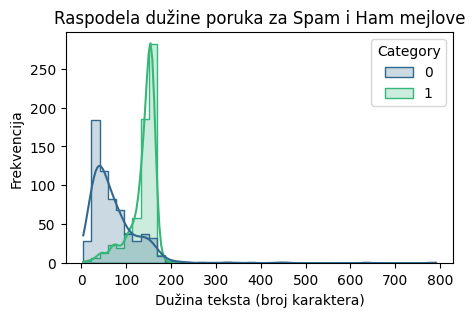

In [27]:
plt.figure(figsize=(5, 3))

# Kreiranje histograma
sb.histplot(data=data_balanced, x='length', hue='Category', kde=True, element="step", palette='viridis')

plt.title('Raspodela dužine poruka za Spam i Ham mejlove')
plt.xlabel('Dužina teksta (broj karaktera)')
plt.ylabel('Frekvencija')
plt.show()

## Text embedding - SBERT


**Metoda reprezentacije teksta** - Sentence Tranformers SBERT  
Ukratko, BERT(Bidirectional encoder representations from transformers) algoritmi predstavljaju "dvosmerne" algoritme koji su prethodno trenirani da predvide skrivene tokene u rečenici kao i da predvide da li jedna rečenica sledi drugu. Jedan od modela treniranih na taj način je i model koji ćemo mi koristiti, *all-MiniLM-L12-v2* model, on je treniran na više od milijardu parova različitih rečenica. On mapira rečenice u 384-dimenzionalne vektore i on uzima u obzir semantiku cele rečenice.

In [28]:
warnings.filterwarnings('ignore')

model_lm = SentenceTransformer(PRETRAINED_LM)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/352 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [29]:
vec = model_lm.encode('Leaving on a soutern train')
print(vec[:5])

[ 0.05946921 -0.11505122 -0.01577082  0.0373367   0.07644535]


In [30]:
len(vec)

384

## Preprocesiranje

Podela na trning i test deo

In [43]:
df_train, df_test = train_test_split(data_balanced, test_size=0.2, random_state=RAND_STATE)

Enkodiranje teksta

In [44]:
print("Enkodiranje trening teksta...")
embeddings_train = model_lm.encode(df_train['Message'].tolist(), show_progress_bar=True)
print("Enkodiranje test teksta...")
embeddings_test = model_lm.encode(df_test['Message'].tolist(), show_progress_bar=True)

Enkodiranje trening teksta...


Batches:   0%|          | 0/33 [00:00<?, ?it/s]

Enkodiranje test teksta...


Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Skaliranje numericke kolone - duzina teksta

In [45]:
scaler = MinMaxScaler()

In [46]:
lengths_train_scaled = scaler.fit_transform(df_train[['length']].values)

In [47]:
lengths_test_scaled = scaler.transform(df_test[['length']].values)

Spajanje podataka

In [49]:
X_train = np.hstack((embeddings_train, lengths_train_scaled))
y_train = df_train['Category'].values

In [51]:
X_train.shape

(1025, 385)

In [53]:
X_test = np.hstack((embeddings_test, lengths_test_scaled))
y_test = df_test['Category'].values

In [55]:
X_test.shape

(257, 385)

Prebacivanje podataka u tenzore

In [56]:
train_features = torch.tensor(X_train, dtype=torch.float32)
train_labels = torch.tensor(y_train, dtype=torch.long)

test_features = torch.tensor(X_test, dtype=torch.float32)
test_labels = torch.tensor(y_test, dtype=torch.long)

## Podela trening skupa na trening i validacioni deo  

In [61]:
train_dataset = TensorDataset(train_features, train_labels)

In [63]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

In [64]:
print(train_size)
print(val_size)

820
205


In [65]:
split_generator = torch.Generator().manual_seed(42)

In [67]:
train_data, val_data = random_split(
    train_dataset,
    [train_size, val_size],
    generator=split_generator
)

In [68]:
print("Broj primera u trening skupu:", len(train_data))
print("Broj primera u validacionom skupu:", len(val_data))

Broj primera u trening skupu: 820
Broj primera u validacionom skupu: 205


## Pravljenje DataLoader-a


In [69]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(test_features, test_labels), batch_size=64, shuffle=False)

## Definisanje modela

In [71]:


class FeedForwardNetDropout(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(385, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)

        self.fc4 = nn.Linear(64, 2)

        self.dropout = nn.Dropout(0.2)

    def forward(self, x):


        x = x.view(x.shape[0], -1)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.dropout(F.relu(self.fc3(x)))


        x = self.fc4(x)

        return x

##Instanciranje modela

In [82]:
model = FeedForwardNetDropout()

## Definisanje funkcije greske i ADAM optimizatora

In [83]:


criterion = nn.CrossEntropyLoss()


optimizer = Adam(
    model.parameters(),
    lr=0.0001
)

## Early stopping

In [84]:
class EarlyStopping:

    def __init__(self, patience=5, delta=0.0):
        self.patience = patience
        self.delta = delta

        self.best_loss = float("inf")
        self.no_improvement_count = 0
        self.stop_training = False

    def check_early_stop(self, val_loss, model):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0

            torch.save(model.state_dict(), "best_model_early_stopping.pth")

        else:
            self.no_improvement_count += 1

            if self.no_improvement_count >= self.patience:
                self.stop_training = True
                print("Early stopping aktiviran.")

In [86]:
early_stopping = EarlyStopping(delta=0.001)

## Treniranje modela uz primenu Early Stopping-a

In [87]:
num_epochs = 40

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    model.train()
    train_loss = 0

    for features, labels in train_loader:

        outputs = model(features)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for features, labels in val_loader:
            outputs = model(features)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoha {epoch + 1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    early_stopping.check_early_stop(avg_val_loss, model)

    if early_stopping.stop_training:
        print(f"Trening zaustavljen u epohi {epoch + 1}")
        break

    print()

Epoha 1/40 | Train Loss: 0.6930 | Val Loss: 0.6895

Epoha 2/40 | Train Loss: 0.6902 | Val Loss: 0.6861

Epoha 3/40 | Train Loss: 0.6866 | Val Loss: 0.6809

Epoha 4/40 | Train Loss: 0.6795 | Val Loss: 0.6724

Epoha 5/40 | Train Loss: 0.6691 | Val Loss: 0.6582

Epoha 6/40 | Train Loss: 0.6538 | Val Loss: 0.6383

Epoha 7/40 | Train Loss: 0.6300 | Val Loss: 0.6115

Epoha 8/40 | Train Loss: 0.6000 | Val Loss: 0.5767

Epoha 9/40 | Train Loss: 0.5610 | Val Loss: 0.5307

Epoha 10/40 | Train Loss: 0.5074 | Val Loss: 0.4734

Epoha 11/40 | Train Loss: 0.4447 | Val Loss: 0.4074

Epoha 12/40 | Train Loss: 0.3761 | Val Loss: 0.3402

Epoha 13/40 | Train Loss: 0.3115 | Val Loss: 0.2816

Epoha 14/40 | Train Loss: 0.2518 | Val Loss: 0.2342

Epoha 15/40 | Train Loss: 0.2085 | Val Loss: 0.2002

Epoha 16/40 | Train Loss: 0.1679 | Val Loss: 0.1782

Epoha 17/40 | Train Loss: 0.1459 | Val Loss: 0.1625

Epoha 18/40 | Train Loss: 0.1264 | Val Loss: 0.1523

Epoha 19/40 | Train Loss: 0.1109 | Val Loss: 0.1442

Ep

In [88]:
results = pd.DataFrame({
    "Epoha": range(1, 31),
    "Train loss": train_losses,
    "Validation loss": val_losses
})

print(results)

    Epoha  Train loss  Validation loss
0       1    0.692954         0.689493
1       2    0.690190         0.686096
2       3    0.686644         0.680905
3       4    0.679494         0.672361
4       5    0.669097         0.658208
5       6    0.653821         0.638281
6       7    0.629952         0.611515
7       8    0.599979         0.576698
8       9    0.561043         0.530741
9      10    0.507360         0.473381
10     11    0.444706         0.407391
11     12    0.376125         0.340168
12     13    0.311462         0.281605
13     14    0.251816         0.234207
14     15    0.208511         0.200184
15     16    0.167947         0.178185
16     17    0.145871         0.162490
17     18    0.126437         0.152273
18     19    0.110924         0.144224
19     20    0.099787         0.139134
20     21    0.091034         0.134844
21     22    0.086884         0.132335
22     23    0.079548         0.131099
23     24    0.069159         0.130975
24     25    0.064616    

## Predikcije modela

In [92]:
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for features, labels in test_loader:
        outputs = model(features)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_preds.extend(predicted.numpy())

y_true = np.array(all_labels)
y_pred = np.array(all_preds)




In [94]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=["Regularni (Ham)", "Nepozeljni (Spam)"]))

                   precision    recall  f1-score   support

  Regularni (Ham)       0.96      0.94      0.95       138
Nepozeljni (Spam)       0.93      0.95      0.94       119

         accuracy                           0.95       257
        macro avg       0.94      0.95      0.95       257
     weighted avg       0.95      0.95      0.95       257



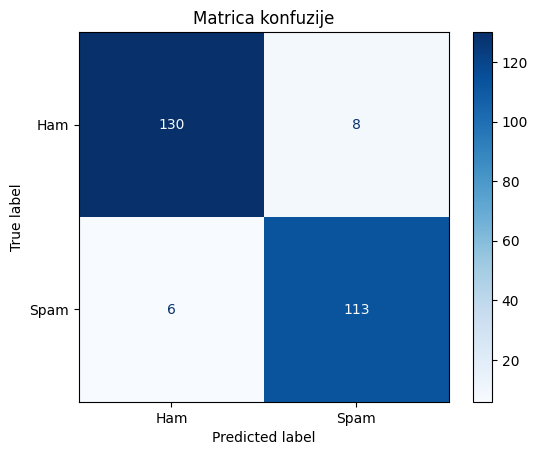

In [102]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap="Blues")
plt.title("Matrica konfuzije")
plt.show()

In [103]:
print(cm)

[[130   8]
 [  6 113]]
